In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

we use head beacuse we want to check wheater th data is imported or not

In [157]:
df=pd.read_csv("tech_job_market_2019_2026 (1).csv")
df.head()
     

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [158]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


In [159]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [160]:

print('duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()

duplicate rows: 1193


here we deleted all the dublicated rows from the data

In [161]:
df.isnull().sum().count()

np.int64(28)

now i will clean the data columb wise

In [162]:
df['sector'].value_counts()

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

In [163]:
df['sector'] = df['sector'].str.strip().str.upper()

with this all the with same name but with diff format become same 

In [164]:
df['work_mode'].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

In [165]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

with this all the with same name but with diff format become same 

In [166]:
df['work_mode'] = df['work_mode'].replace({
    'work from home': 'remote',
    'wfh': 'remote',
    'on-site': 'onsite',
    'in-office': 'onsite',
    'office': 'onsite'
})


now work mode is aslo became similar data type 

In [167]:
df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace({"False": 0, "No": 0, "N": 0, "0": 0,"True": 1, "Yes": 1, "Y": 1, "1": 1})

In [168]:
df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace( {"False": 0, "No": 0, "N": 0, "True": 1, "Yes": 1, "Y": 1, "0": 0, "1": 1})

here we clean yes no or ttue or flase with 1 and 0

In [169]:

df['salary_min_usd'] = df['salary_min_usd'].str.replace(',', '', regex=False)
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df['salary_min_usd'] = df['salary_min_usd'].replace(-1, np.nan)
df['salary_min_usd'] = df['salary_min_usd'].fillna(df['salary_min_usd'].mean())

In [170]:

df['salary_max_usd'] = df['salary_max_usd'].str.replace(',', '', regex=False)
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')
df['salary_max_usd'] = df['salary_max_usd'].replace(-1, np.nan)
df['salary_max_usd'] = df['salary_max_usd'].fillna(df['salary_max_usd'].mean())


In [171]:
(df['salary_min_usd'] > df['salary_max_usd']).sum()

np.int64(1009)

In [172]:
m = df['salary_min_usd'] > df['salary_max_usd']
df.loc[m, ['salary_min_usd', 'salary_max_usd']] = df.loc[m, ['salary_max_usd', 'salary_min_usd']].values

In [173]:
(df['salary_min_usd'] > df['salary_max_usd']).sum()

np.int64(0)

here we are converitng the salary into numeric if it doext so it save as nan as we use errors coerce and we also fill missing place with mean and check for the min and max are in corecr order or not and fixed it 

In [174]:
(df['years_experience_min'] > df['years_experience_max']).sum()

np.int64(315)

In [175]:
p = df['years_experience_min'] > df['years_experience_max']
df.loc[p, ['years_experience_min', 'years_experience_max']] = df.loc[p, ['years_experience_max', 'years_experience_min']].values

In [176]:
(df['years_experience_min'] > df['years_experience_max']).sum()   

np.int64(0)

In [177]:

df['primary_programming_language'] = df['primary_programming_language'].fillna('Unknown')
df['job_location_city'] = df['job_location_city'].fillna('Unknown')
df['number_of_applicants'] = df['number_of_applicants'].fillna(df['number_of_applicants'].median())
df['number_of_interview_rounds'] = df['number_of_interview_rounds'].fillna(df['number_of_interview_rounds'].median())
df['offers_extended'] = df['offers_extended'].fillna(df['offers_extended'].median())
df['offers_accepted'] = df['offers_accepted'].fillna(df['offers_accepted'].median())


filling those data AS unknow WHICH cant filled or predict

In [178]:
(df['number_of_applicants'] < 0).sum()

np.int64(243)

In [179]:
df.loc[df['number_of_applicants'] < 0, 'number_of_applicants'] = np.nan

In [180]:
(df['number_of_applicants'] < 0).sum()

np.int64(0)

In [181]:
df['number_of_applicants'] = df['number_of_applicants'].fillna(df['number_of_applicants'].median())

In [182]:
(df['offers_accepted'] > df['offers_extended']).sum()

np.int64(591)

In [183]:
offer_mask = df['offers_accepted'] > df['offers_extended']
df.loc[offer_mask, ['offers_extended', 'offers_accepted']] = df.loc[offer_mask, ['offers_accepted', 'offers_extended']].values

In [184]:
(df['offers_accepted'] > df['offers_extended']).sum()  

np.int64(0)

In [185]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language        0
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city                   0
salary_currency                     0
posting_date                        0
application_deadline             5695
date_position_filled            25514
position_status                     0
number_of_applicants                0
number_of_interview_rounds          0
offers_extended                     0
offers_accepted                     0
salary_min_usd                      0
salary_max_u

In [186]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd
count,113807.000000,113807.000000,113807.000000,113807.000000,113807.000000,113807.000000,113807.000000,113807.000000,1.138070e+05
mean,105407.621552,2.993032,6.675266,181.431248,3.306352,1.355874,1.188266,115149.037840,1.429267e+05
std,102128.678701,3.076324,5.074163,435.641006,1.415474,1.459051,1.113777,55480.263515,8.921157e+04
min,10.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1700.000000,1.590000e+04
25%,6044.500000,1.000000,3.000000,63.000000,2.000000,1.000000,1.000000,77900.000000,9.480000e+04
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000,108800.000000,1.322000e+05
75%,169835.500000,5.000000,9.000000,212.000000,4.000000,1.000000,1.000000,143100.000000,1.751000e+05
max,488674.000000,13.000000,24.000000,36816.000000,8.000000,10.000000,8.000000,531800.000000,3.552000e+06


In [187]:
(df['number_of_applicants'] > 5000).sum()


np.int64(141)

In [188]:
(df['salary_max_usd'] > 1000000).sum()

np.int64(132)

univarent 

1- histogram

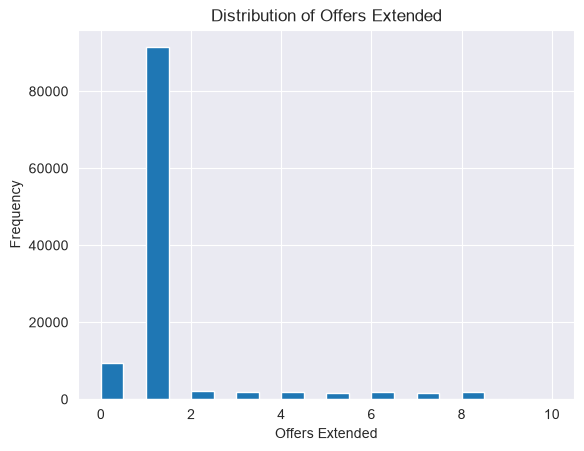

In [189]:
plt.hist( df['offers_extended'], bins=20 )
plt.xlabel('Offers Extended')
plt.ylabel('Frequency')
plt.title('Distribution of Offers Extended')
plt.show()



<Axes: xlabel='offers_extended', ylabel='number_of_applicants'>

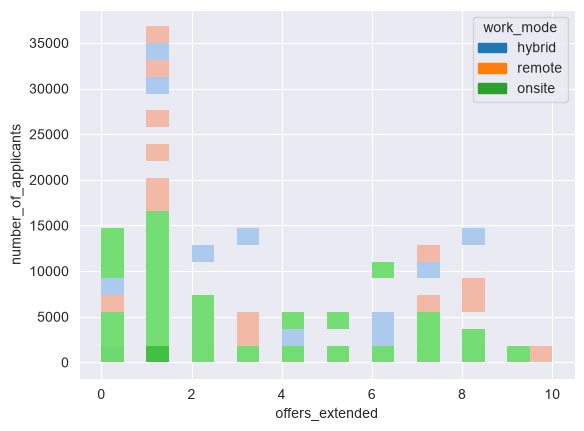

In [190]:
sns.histplot(data=df, x='offers_extended',y='number_of_applicants', hue='work_mode', bins=20, )

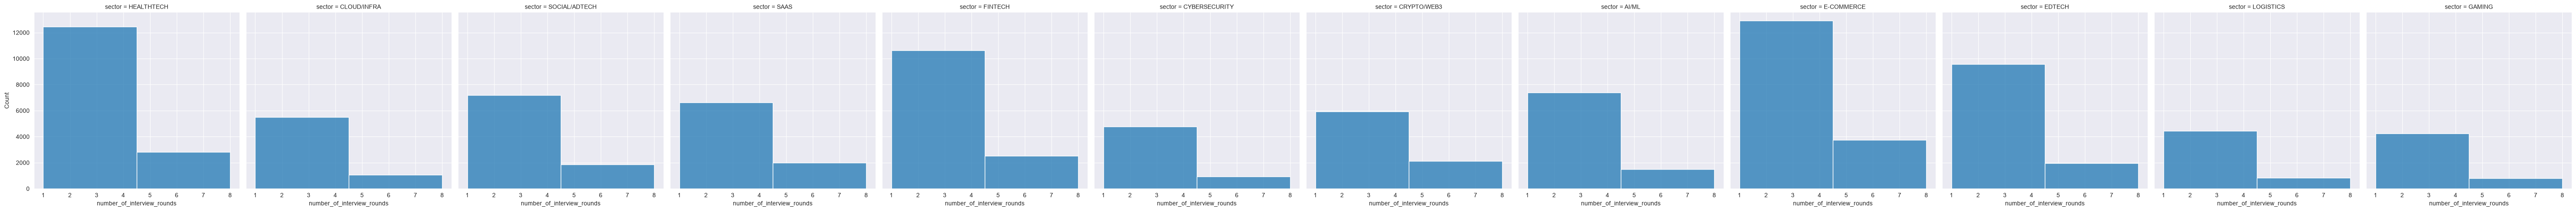

In [191]:
sns.displot(data=df, x='number_of_interview_rounds', kind='hist',bins=2,col='sector')

In [192]:
2 #kdeplot

2

<Axes: xlabel='number_of_applicants', ylabel='Density'>

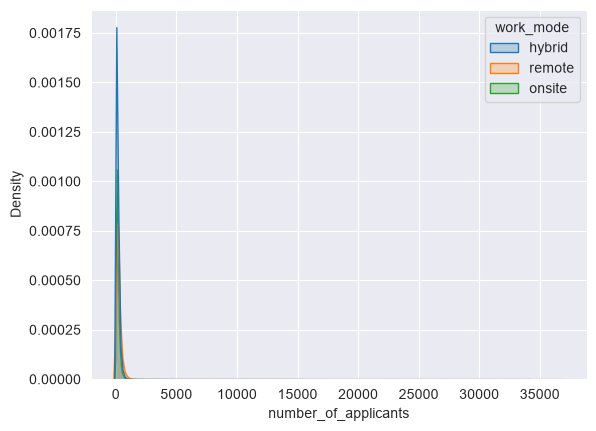

In [193]:
sns.kdeplot(data=df,x='number_of_applicants',hue='work_mode',fill=True)

<Axes: xlabel='years_experience_min', ylabel='Density'>

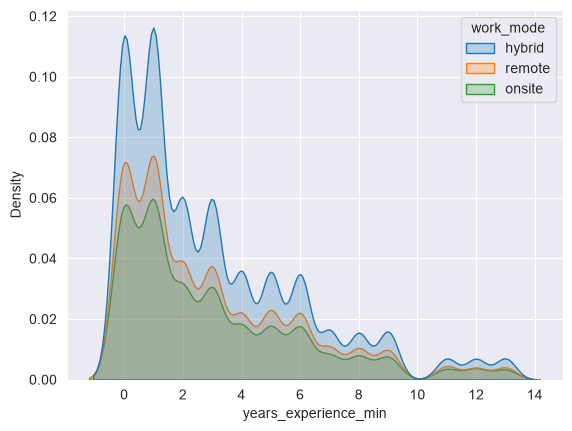

In [194]:
sns.kdeplot(data=df,x='years_experience_min',hue='work_mode',fill=True)

rug plot

<Axes: xlabel='offers_extended'>

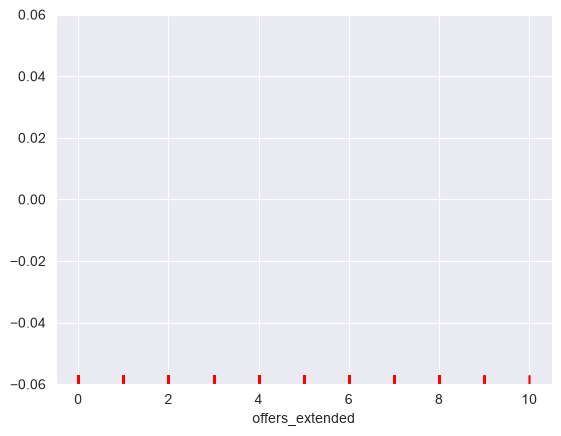

In [195]:
#sns.kdeplot(data=df,x='number_of_applicants',hue='work_mode',fill=True)
sns.rugplot(data=df,x='offers_extended',color='red')

piechart for univarnet 

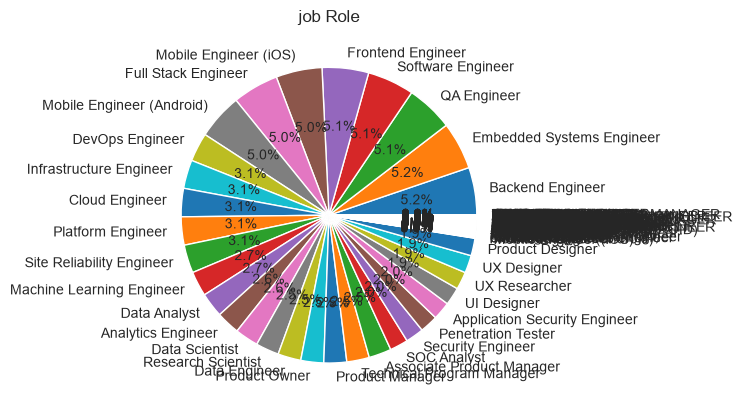

In [196]:
df['job_role'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.ylabel('')
plt.title('job Role')
plt.show()

In [197]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0    78079
1    35728
Name: count, dtype: int64

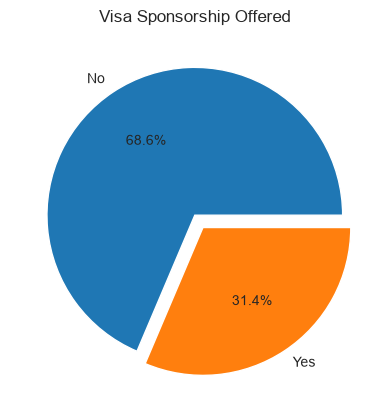

In [198]:
df['visa_sponsorship_offered'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['No', 'Yes'],explode=[0, 0.1])
plt.ylabel('')
plt.title('Visa Sponsorship Offered')
plt.show()

In [199]:
#bivarent 

scatter

<Axes: xlabel='visa_sponsorship_offered', ylabel='number_of_applicants'>

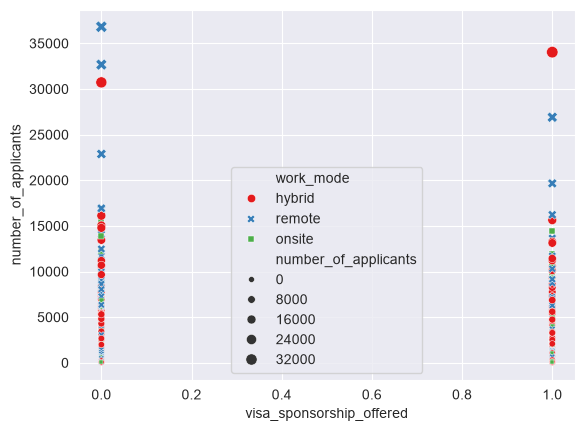

In [200]:
sns.scatterplot(data=df, x='visa_sponsorship_offered', y='number_of_applicants',style='work_mode',size='number_of_applicants',hue='work_mode',palette='Set1')

line


<Axes: xlabel='years_experience_min', ylabel='offers_extended'>

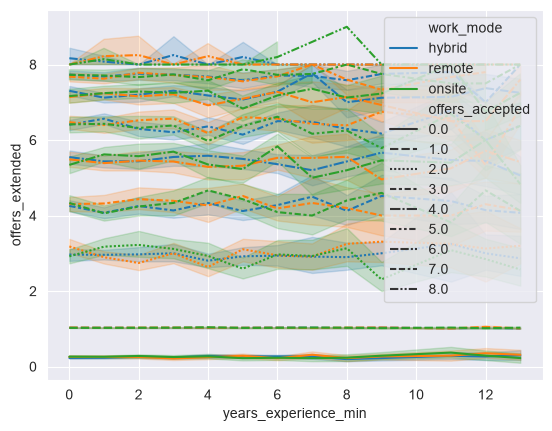

In [201]:
sns.lineplot(data=df, x='years_experience_min', y='offers_extended',hue='work_mode',style='offers_accepted')

<Axes: xlabel='position_status', ylabel='number_of_applicants'>

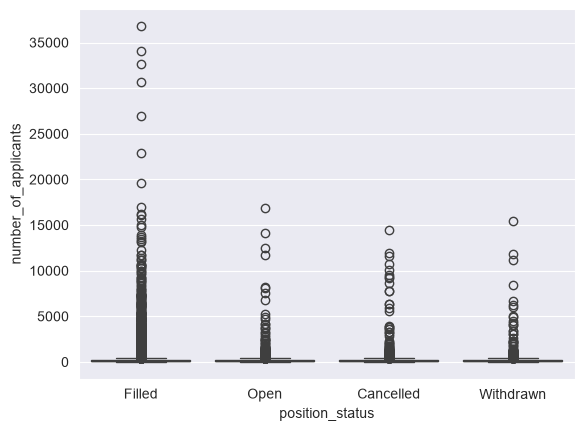

In [202]:
sns.boxplot(x='position_status', y='number_of_applicants', data=df)

In [203]:
top_languages = df['primary_programming_language'].value_counts().head(10)

<Axes: ylabel='primary_programming_language'>

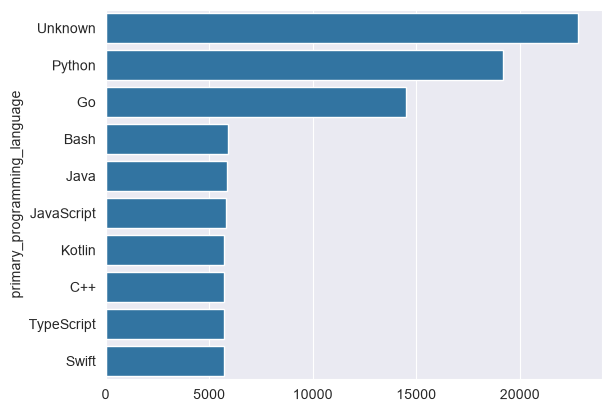

In [204]:


sns.barplot(x=top_languages.values, y=top_languages.index)

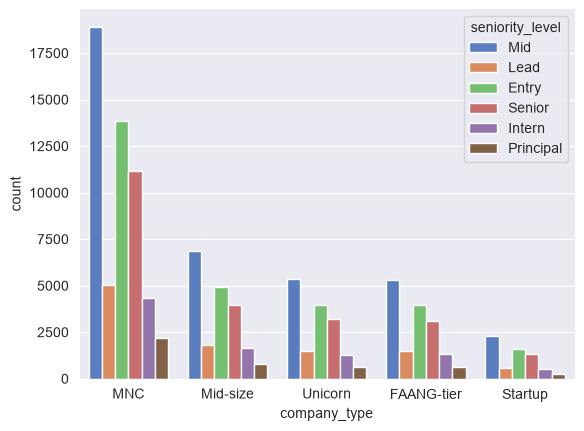

In [205]:

sns.countplot(data=df, x="company_type", hue="seniority_level", palette="muted")
sns.despine()

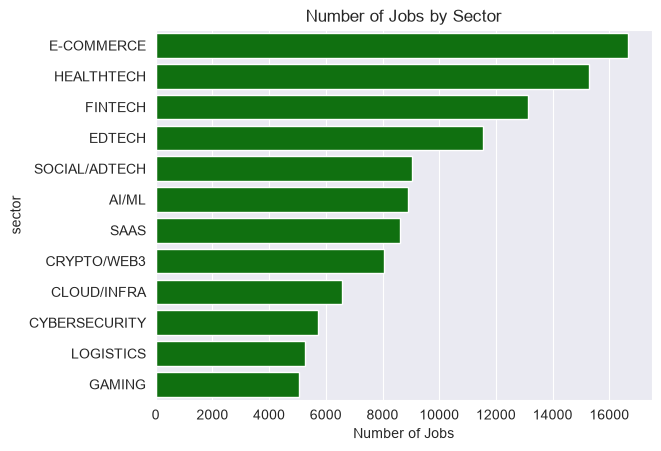

In [206]:
sns.countplot(data=df, y='sector',order=df['sector'].value_counts().index, color="green")
plt.title("Number of Jobs by Sector")
plt.xlabel("Number of Jobs")
plt.show()

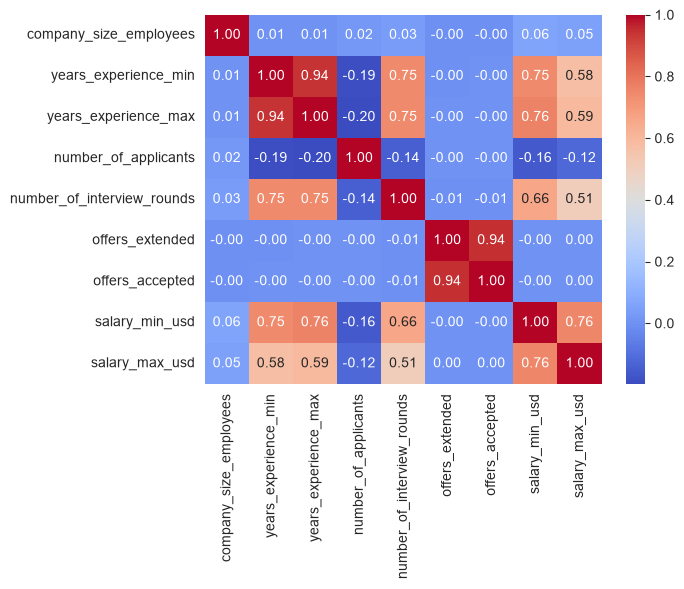

In [207]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

 Conclusions
- salary and date columns needed cleaning before use
- work_mode, sector, visa, layoff columns had inconsistent spellings, fixed
- experience swap and offers_accepted=0 fixed where the reason was clear, other issues (negative applicants, remaining offer mismatch, duplicate job_id) left as is and documented
